In [1]:
import gzip
import numpy as np
import pickle
import math
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

Load Data

In [2]:
paths = [
    "/Users/rachelouyang/Desktop/Research/Transient/ProbCube_Data/ProbCube_1229_0821__SNIa-SALT2.pkl",
    "/Users/rachelouyang/Desktop/Research/Transient/ProbCube_Data/ProbCube_1229_1815__SNII-Templates.pkl",
    "/Users/rachelouyang/Desktop/Research/Transient/ProbCube_Data/ProbCube_1229_0821__SNIbc-Templates.pkl",
    "/Users/rachelouyang/Desktop/Research/Transient/ProbCube_Data/ProbCube_1229_1822__SLSN-I.pkl",
    "/Users/rachelouyang/Desktop/Research/Transient/ProbCube_Data/ProbCube_1229_0821__TDE.pkl",
    "/Users/rachelouyang/Desktop/Research/Transient/ProbCube_Data/ProbCube_1229_1819__AGN.pkl",
    "/Users/rachelouyang/Desktop/Research/Transient/ProbCube_Data/ProbCube_1229_1827__RRL.pkl",
    "/Users/rachelouyang/Desktop/Research/Transient/ProbCube_Data/ProbCube_0402_0307__KN_B19_full.pkl.gz",
]

coordinate_dicts = [None] * len(paths)
data = [None] * len(paths)

for i, path in enumerate(paths):
    opener = gzip.open if path.endswith(".gz") else open

    with opener(path, "rb") as f:
        coordinate_dicts[i] = pickle.load(f)
        data[i] = pickle.load(f)

In [ ]:
Names = [
    "SNIa",
    "SNII",
    "SNIbc",
    "SLSN",
    "TDE",
    "AGN",
    "RRL",
    "KN"
]

DataDict = {}

for i, name in enumerate(Names):
    cube = data[i]

    if not isinstance(cube, np.ndarray):
        raise TypeError(
            f"{name}: expected data[{i}] to be a NumPy array, "
            f"but found {type(cube)}"
        )

    DataDict[name] = {
        "data": cube,
        "coordinate_dict": coordinate_dicts[i],
        "shape": cube.shape,
        "sum_total": np.sum(cube, dtype=np.float64),

        # Axis definitions
        "band_pairs_axis": 0,
        "time_pairs_axis": 1,
        "mag_axis": 2,
        "color_axis": 3,
    }

In [7]:
# check

for name in Names:
    print(
        name,
        DataDict[name]["shape"],
        DataDict[name]["data"].dtype,
        DataDict[name]["sum_total"],
    )

SNIa (28, 3603, 110, 38) float64 30056405420.0
SNII (28, 3603, 110, 38) float64 19565324536.0
SNIbc (28, 3603, 110, 38) float64 12806957280.0
SLSN (28, 3603, 110, 38) float64 40741675245.0
TDE (28, 3603, 110, 38) float64 24563436811.0
AGN (28, 3603, 110, 38) float64 19245774932.0
RRL (28, 3603, 110, 38) float64 47944553959.0
KN (28, 3603, 110, 38) float64 320466605.0


Normalization

In [17]:
def normalize_conditional(data_array):
    """
    Compute p(Δm, color | band pair, time pair).

    Expected shape:
        (band_pair, time_pair, mag_bin, color_bin)
    """
    data_float = np.asarray(data_array, dtype=np.float64)

    denominator = data_float.sum(
        axis=(2, 3),
        keepdims=True
    )

    kernel = np.divide(
        data_float,
        denominator,
        out=np.zeros_like(data_float),
        where=denominator > 0,
    )

    return kernel

def normalize_conditional_slice(data_array, b, t):
    """
    Compute p(Δm, color | b, t) for one selected slice.
    """
    slice_counts = np.asarray(
        data_array[b, t, :, :],
        dtype=np.float64
    )

    total = slice_counts.sum()

    if total == 0:
        return np.zeros_like(slice_counts)

    return slice_counts / total

Visualization of Kernel

In [18]:
for name in Names:
    DataDict[name]["kernel"] = normalize_conditional(
        DataDict[name]["data"]
    )

In [25]:
# Choose representative time pairs

tp = DataDict["SNII"]["coordinate_dict"]["TimePairs"]

dt1_values = [-465, -210, 0, 210, 465]
dt2_values = [-1500, -480, 0, 480, 1500]

time_indices = []
time_pairs = []

for dt1 in dt1_values:
    for dt2 in dt2_values:

        target = np.array([dt1, dt2])

        idx = np.where((tp == target).all(axis=1))[0]

        if len(idx) == 1:
            time_pairs.append((dt1, dt2))
            time_indices.append(int(idx[0]))

print("Candidate time pairs:")
for pair, idx in zip(time_pairs, time_indices):
    print(f"{pair}  -->  t={idx}")

Candidate time pairs:
(-465, -1500)  -->  t=65
(-465, 0)  -->  t=68
(-465, 480)  -->  t=84
(-465, 1500)  -->  t=87
(-210, -1500)  -->  t=935
(-210, -480)  -->  t=938
(-210, 0)  -->  t=941
(-210, 480)  -->  t=957
(-210, 1500)  -->  t=960
(0, -1500)  -->  t=1782
(0, -480)  -->  t=1785
(0, 0)  -->  t=1801
(0, 480)  -->  t=1817
(0, 1500)  -->  t=1820
(210, -1500)  -->  t=2642
(210, -480)  -->  t=2645
(210, 0)  -->  t=2661
(210, 480)  -->  t=2664
(210, 1500)  -->  t=2667
(465, -1500)  -->  t=3515
(465, -480)  -->  t=3518
(465, 0)  -->  t=3534
(465, 1500)  -->  t=3537


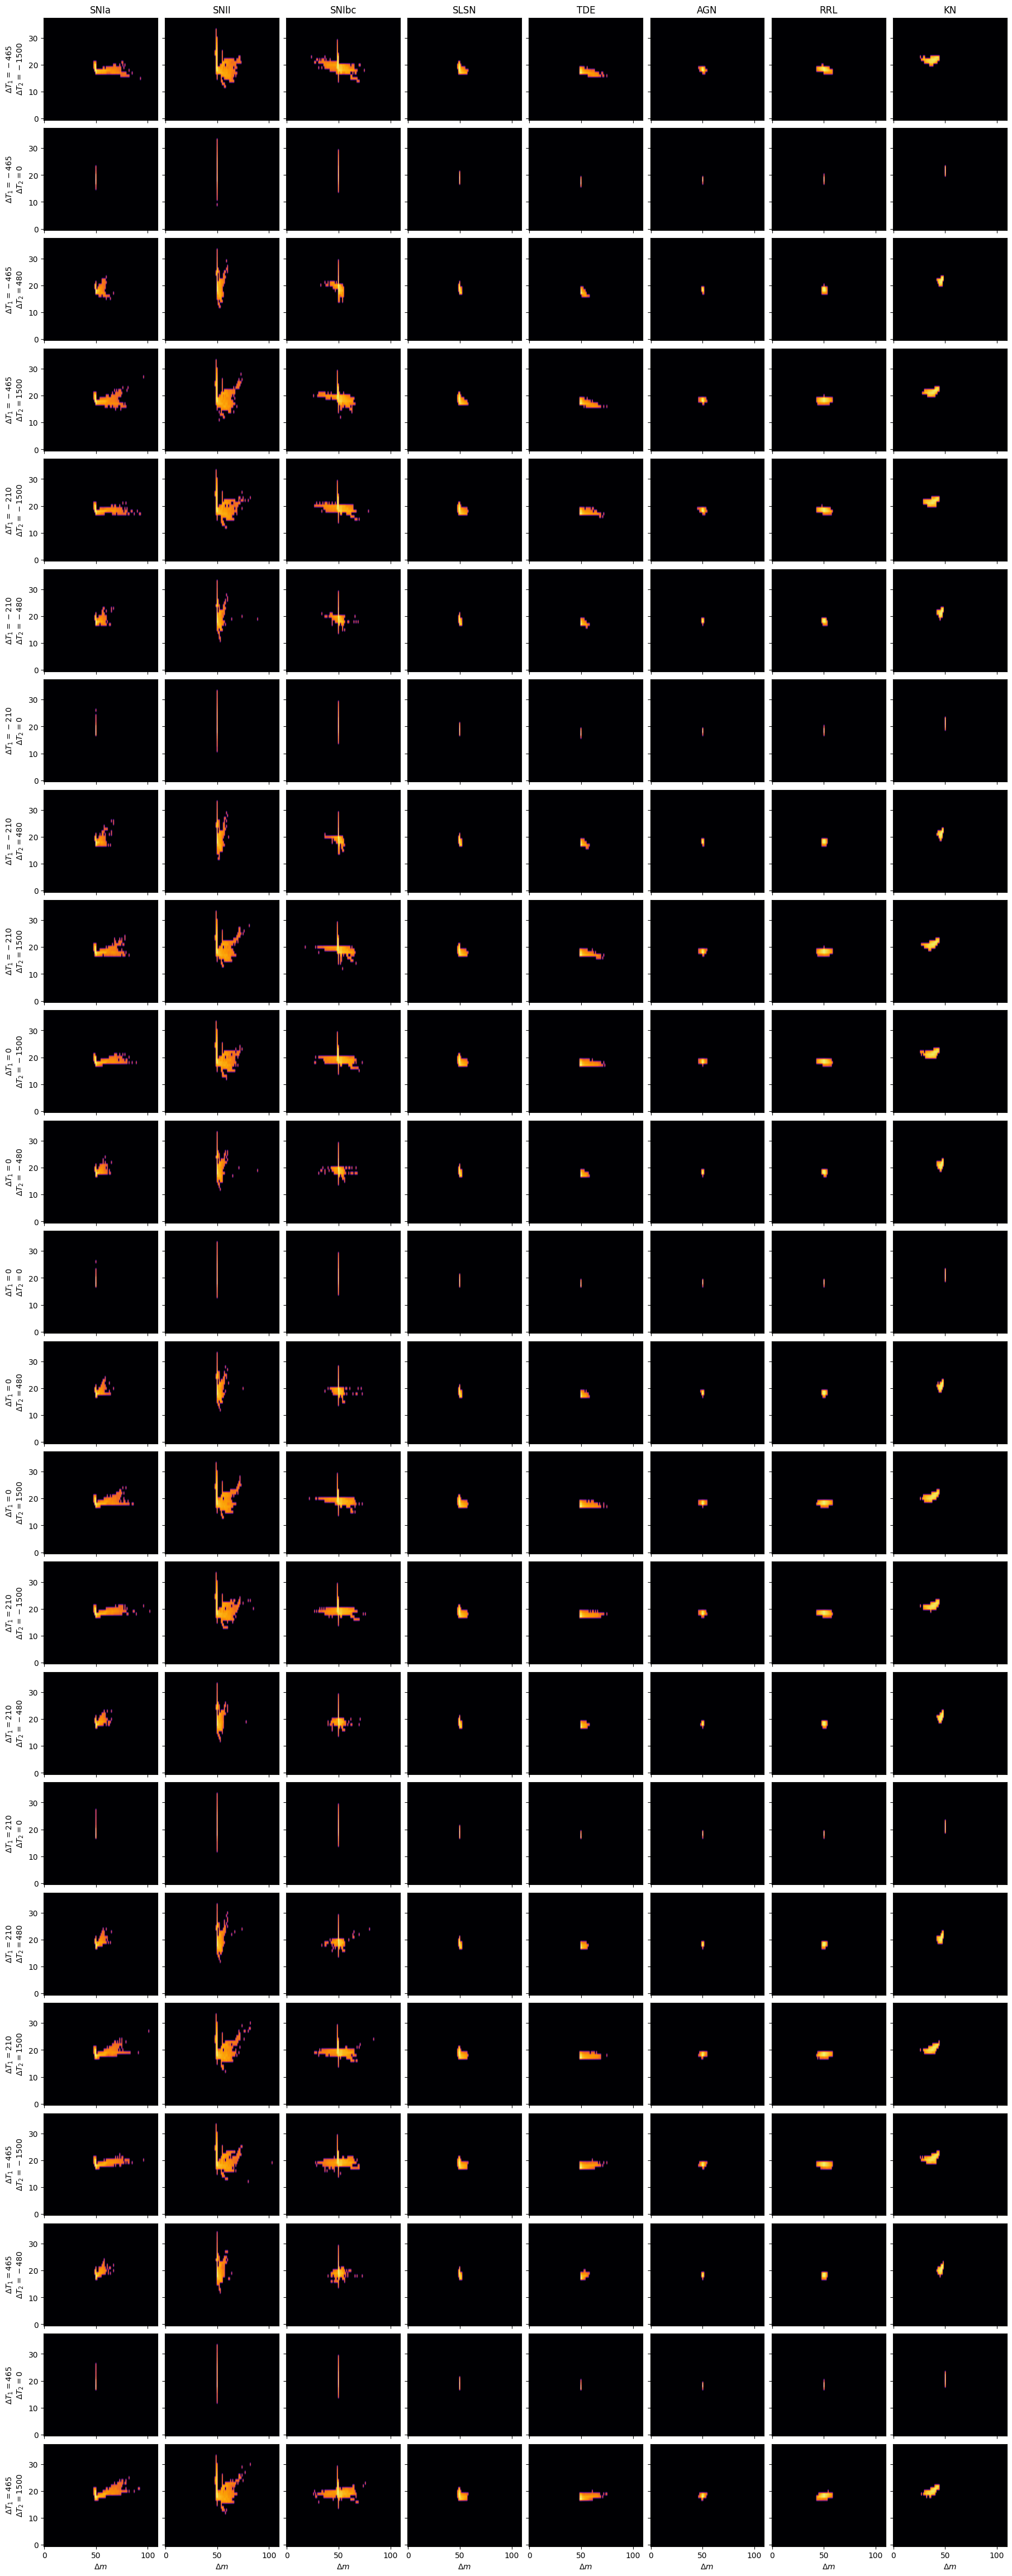

In [30]:
b_fixed = 5      # gr

fig, axes = plt.subplots(
    len(time_indices),
    len(Names),
    figsize=(18, 2 * len(time_indices)),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for row, (t, pair) in enumerate(zip(time_indices, time_pairs)):
    for col, name in enumerate(Names):

        ax = axes[row, col]

        K = DataDict[name]["kernel"][b_fixed, t]

        ax.imshow(
            np.log10(np.clip(K, 1e-16, None)).T,
            origin="lower",
            aspect="auto",
            cmap="inferno",
            vmin=-16,
            vmax=0,
        )

        if row == 0:
            ax.set_title(name)

        if col == 0:
            ax.set_ylabel(
                rf"$\Delta T_1={pair[0]}$"
                "\n"
                rf"$\Delta T_2={pair[1]}$"
            )

        if row == len(time_indices)-1:
            ax.set_xlabel(r"$\Delta m$")

plt.show()

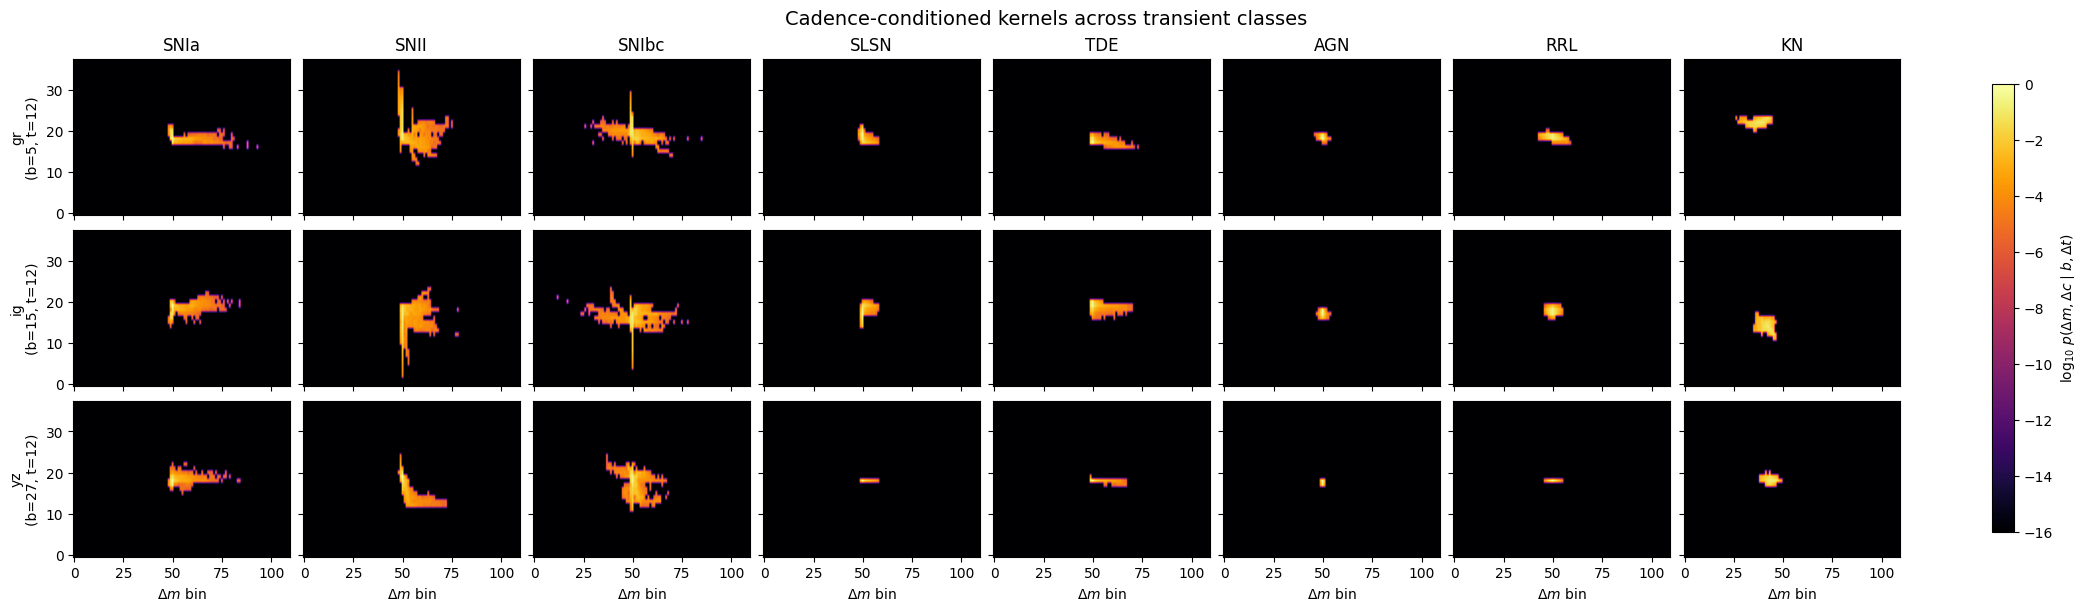

In [ ]:
# Fixed time pair

pair_band_final = [
    (5, 12),
    (15, 12),
    (27, 12),
]

fig, axes = plt.subplots(
    nrows=len(pair_band_final),
    ncols=len(Names),
    figsize=(2.6 * len(Names), 6),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for row, (b, t) in enumerate(pair_band_final):
    for col, cls in enumerate(Names):

        ax = axes[row, col]

        K = DataDict[cls]["kernel"][b, t]

        logK = np.log10(
            np.clip(K, 1e-16, None)
        )

        im = ax.imshow(
            logK.T,
            origin="lower",
            aspect="auto",
            cmap="inferno",
            vmin=-16,
            vmax=0,
        )

        # Titles
        if row == 0:
            ax.set_title(cls)

        # Row labels
        if col == 0:
            band_pair = DataDict[cls]["coordinate_dict"]["BandPairs"][b]

            ax.set_ylabel(
                f"{band_pair}\n(b={b}, t={t})"
            )

        # Bottom labels
        if row == len(pair_band_final) - 1:
            ax.set_xlabel(r"$\Delta m$ bin")

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    location="right",
    shrink=0.9,
)

cbar.set_label(
    r"$\log_{10}\,p(\Delta m,\Delta c\mid b,\Delta t)$"
)

fig.suptitle("Cadence-conditioned kernels across transient classes", fontsize=14)

plt.show()

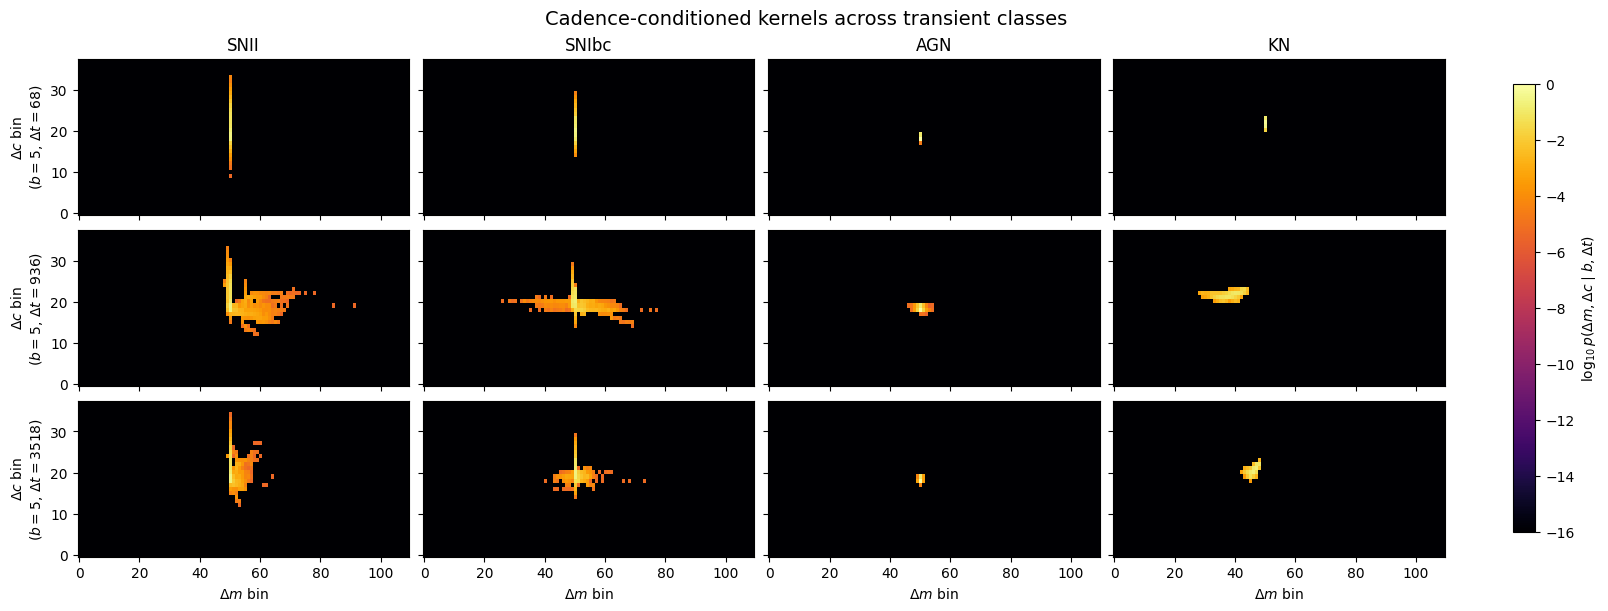

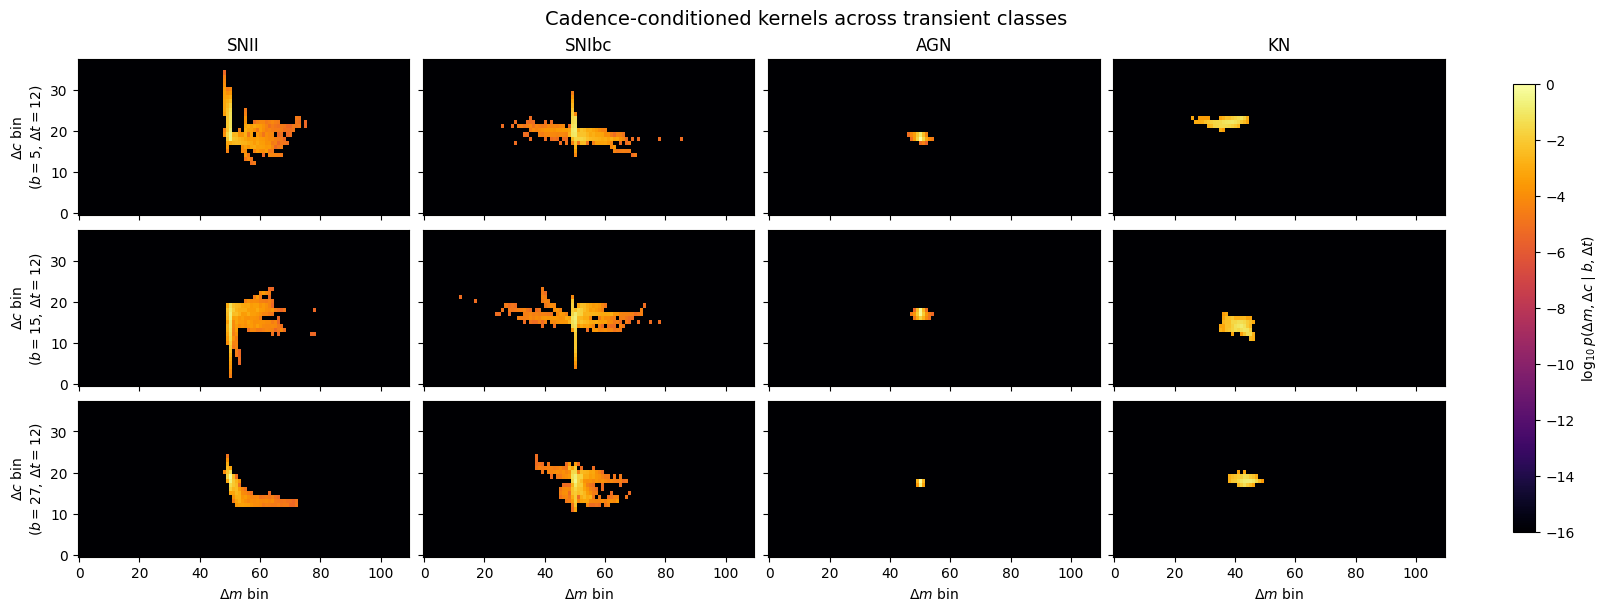

In [33]:
plot_classes = [
    "SNII",
    "SNIbc",
    "AGN",
    "KN",
]

# figure 1

plot_classes = ["SNII", "SNIbc", "AGN", "KN"]

pair_time_final = [
    (5, 68),
    (5, 936),
    (5, 3518),
]

fig, axes = plt.subplots(
    nrows=len(pair_time_final),
    ncols=len(plot_classes),
    figsize=(16, 6),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for row, (b, t) in enumerate(pair_time_final):
    for col, cls in enumerate(plot_classes):
        ax = axes[row, col]

        K = DataDict[cls]["kernel"][b, t]

        logK = np.log10(
            np.clip(K, 1e-16, None)
        )

        im = ax.imshow(
            logK.T,
            origin="lower",
            aspect="auto",
            cmap="inferno",
            vmin=-16,
            vmax=0,
        )

        if row == 0:
            ax.set_title(cls)

        if col == 0:
            ax.set_ylabel(
                rf"$\Delta c$ bin"
                "\n"
                rf"$(b={b},\,\Delta t={t})$"
            )

        if row == len(pair_time_final) - 1:
            ax.set_xlabel(r"$\Delta m$ bin")

cbar = fig.colorbar(
    im,
    ax=axes,
    location="right",
    shrink=0.9,
)

cbar.set_label(
    r"$\log_{10} p(\Delta m,\Delta c\mid b,\Delta t)$"
)

fig.suptitle(
    "Cadence-conditioned kernels across transient classes",
    fontsize=14,
)

plt.savefig(
    "kernels_time_pairs_four_classes.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# figure 2

pair_band_final = [
    (5, 12),
    (15, 12),
    (27, 12),
]

fig, axes = plt.subplots(
    nrows=len(pair_band_final),
    ncols=len(plot_classes),
    figsize=(16, 6),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for row, (b, t) in enumerate(pair_band_final):
    for col, cls in enumerate(plot_classes):
        ax = axes[row, col]

        K = DataDict[cls]["kernel"][b, t]

        logK = np.log10(
            np.clip(K, 1e-16, None)
        )

        im = ax.imshow(
            logK.T,
            origin="lower",
            aspect="auto",
            cmap="inferno",
            vmin=-16,
            vmax=0,
        )

        if row == 0:
            ax.set_title(cls)

        if col == 0:
            ax.set_ylabel(
                rf"$\Delta c$ bin"
                "\n"
                rf"$(b={b},\,\Delta t={t})$"
            )

        if row == len(pair_band_final) - 1:
            ax.set_xlabel(r"$\Delta m$ bin")

cbar = fig.colorbar(
    im,
    ax=axes,
    location="right",
    shrink=0.9,
)

cbar.set_label(
    r"$\log_{10} p(\Delta m,\Delta c\mid b,\Delta t)$"
)

fig.suptitle(
    "Cadence-conditioned kernels across transient classes",
    fontsize=14,
)

plt.savefig(
    "kernels_band_pairs_four_classes.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Cross Entropy

In [38]:
def cross_entropy_counts(
    p_counts,
    q_counts,
    p_total,
    q_total,
    floor=1e-16,
    chunk_size=2_000_000,
):
    if p_counts.shape != q_counts.shape:
        raise ValueError(
            f"Shape mismatch: {p_counts.shape} vs {q_counts.shape}"
        )

    if p_total <= 0 or q_total <= 0:
        raise ValueError("p_total and q_total must be positive.")

    p_flat = p_counts.reshape(-1)
    q_flat = q_counts.reshape(-1)

    # First pass:
    # calculate the normalization constants after assigning
    # the floor to zero-occupancy bins.
    p_regularized_total = 0.0
    q_regularized_total = 0.0

    for start in range(0, p_flat.size, chunk_size):
        stop = min(start + chunk_size, p_flat.size)

        p_count_chunk = p_flat[start:stop]
        q_count_chunk = q_flat[start:stop]

        p_chunk = (
            np.asarray(
                p_count_chunk,
                dtype=np.float64,
            )
            / p_total
        )

        q_chunk = (
            np.asarray(
                q_count_chunk,
                dtype=np.float64,
            )
            / q_total
        )

        # Apply the floor only to zero-occupancy bins.
        p_chunk = np.where(
            p_count_chunk == 0,
            floor,
            p_chunk,
        )

        q_chunk = np.where(
            q_count_chunk == 0,
            floor,
            q_chunk,
        )

        p_regularized_total += np.sum(
            p_chunk,
            dtype=np.float64,
        )

        q_regularized_total += np.sum(
            q_chunk,
            dtype=np.float64,
        )

    # Second pass:
    # renormalize both PMFs and calculate cross-entropy.
    result = 0.0
    p_sum_check = 0.0
    q_sum_check = 0.0

    for start in range(0, p_flat.size, chunk_size):
        stop = min(start + chunk_size, p_flat.size)

        p_count_chunk = p_flat[start:stop]
        q_count_chunk = q_flat[start:stop]

        p_chunk = (
            np.asarray(
                p_count_chunk,
                dtype=np.float64,
            )
            / p_total
        )

        q_chunk = (
            np.asarray(
                q_count_chunk,
                dtype=np.float64,
            )
            / q_total
        )

        p_chunk = np.where(
            p_count_chunk == 0,
            floor,
            p_chunk,
        )

        q_chunk = np.where(
            q_count_chunk == 0,
            floor,
            q_chunk,
        )

        # Final renormalization
        p_chunk /= p_regularized_total
        q_chunk /= q_regularized_total

        # Sanity-check sums
        p_sum_check += np.sum(
            p_chunk,
            dtype=np.float64,
        )

        q_sum_check += np.sum(
            q_chunk,
            dtype=np.float64,
        )

        result -= np.sum(
            p_chunk * np.log(q_chunk),
            dtype=np.float64,
        )

    if not np.isclose(
        p_sum_check,
        1.0,
        rtol=1e-10,
        atol=1e-12,
    ):
        raise RuntimeError(
            f"Regularized p does not sum to 1: "
            f"{p_sum_check}"
        )

    if not np.isclose(
        q_sum_check,
        1.0,
        rtol=1e-10,
        atol=1e-12,
    ):
        raise RuntimeError(
            f"Regularized q does not sum to 1: "
            f"{q_sum_check}"
        )

    return result

In [39]:
H = np.empty(
    (len(Names), len(Names)),
    dtype=np.float64
)

for i, p_name in enumerate(Names):
    for j, q_name in enumerate(Names):
        H[i, j] = cross_entropy_counts(
            p_counts=DataDict[p_name]["data"],
            q_counts=DataDict[q_name]["data"],
            p_total=DataDict[p_name]["sum_total"],
            q_total=DataDict[q_name]["sum_total"],
        )

        print(
            f"H({p_name}, {q_name}) = "
            f"{H[i, j]:.6f}"
        )

np.save("cross_entropy_8x8.npy", H)

H(SNIa, SNIa) = 13.077262
H(SNIa, SNII) = 14.076667
H(SNIa, SNIbc) = 15.369973
H(SNIa, SLSN) = 14.823492
H(SNIa, TDE) = 20.092009
H(SNIa, AGN) = 22.293186
H(SNIa, RRL) = 18.023655
H(SNIa, KN) = 34.655950
H(SNII, SNIa) = 17.610007
H(SNII, SNII) = 13.620689
H(SNII, SNIbc) = 14.724802
H(SNII, SLSN) = 18.468690
H(SNII, TDE) = 23.265180
H(SNII, AGN) = 24.982507
H(SNII, RRL) = 22.725767
H(SNII, KN) = 34.453116
H(SNIbc, SNIa) = 20.487784
H(SNIbc, SNII) = 15.482205
H(SNIbc, SNIbc) = 14.226121
H(SNIbc, SLSN) = 20.635176
H(SNIbc, TDE) = 28.014977
H(SNIbc, AGN) = 26.706535
H(SNIbc, RRL) = 25.725027
H(SNIbc, KN) = 33.983111
H(SLSN, SNIa) = 14.155999
H(SLSN, SNII) = 13.709699
H(SLSN, SNIbc) = 14.619809
H(SLSN, SLSN) = 12.973083
H(SLSN, TDE) = 18.868151
H(SLSN, AGN) = 17.060484
H(SLSN, RRL) = 19.186360
H(SLSN, KN) = 34.323457
H(TDE, SNIa) = 19.016725
H(TDE, SNII) = 16.639907
H(TDE, SNIbc) = 21.186906
H(TDE, SLSN) = 16.072219
H(TDE, TDE) = 12.596175
H(TDE, AGN) = 29.312585
H(TDE, RRL) = 26.776429
H(T

In [ ]:
# adjusting im figure color

from matplotlib.colors import LinearSegmentedColormap

def create_sequential_cmap(base_color, n_colors=256, name='custom',
                           dark_level=0.2, light_level=1.0):
    """
    Create a sequential colormap with adjustable dark/light limits.

    Parameters:
    - base_color: str or tuple, base color
    - n_colors: int, number of colors in colormap
    - dark_level: float, how dark the darkest shade becomes (0=black, 1=original)
    - light_level: float, how light the lightest shade becomes (1=white, >1=brighter)
    """
    from matplotlib.colors import to_rgb
    rgb = np.array(to_rgb(base_color))

    # Create color array
    colors = []
    for i in range(n_colors):
        # Linear interpolation between dark and light
        t = i / (n_colors - 1)

        # Interpolate between dark and light shades
        dark_shade = rgb * dark_level
        light_shade = np.ones(3) * light_level
        color = dark_shade * (1 - t) + light_shade * t

        # Clip values to valid range [0, 1]
        color = np.clip(color, 0, 1)
        colors.append(color)

    return LinearSegmentedColormap.from_list(name, colors)

purple = '#9b59b6'
cmap_dark = create_sequential_cmap(purple, dark_level=0.1, light_level=0.9, name='purple_dark')
cmap_medium = create_sequential_cmap(purple, dark_level=0.4, light_level=1.0, name='purple_medium')
cmap_light = create_sequential_cmap(purple, dark_level=0.7, light_level=1.0, name='purple_light')

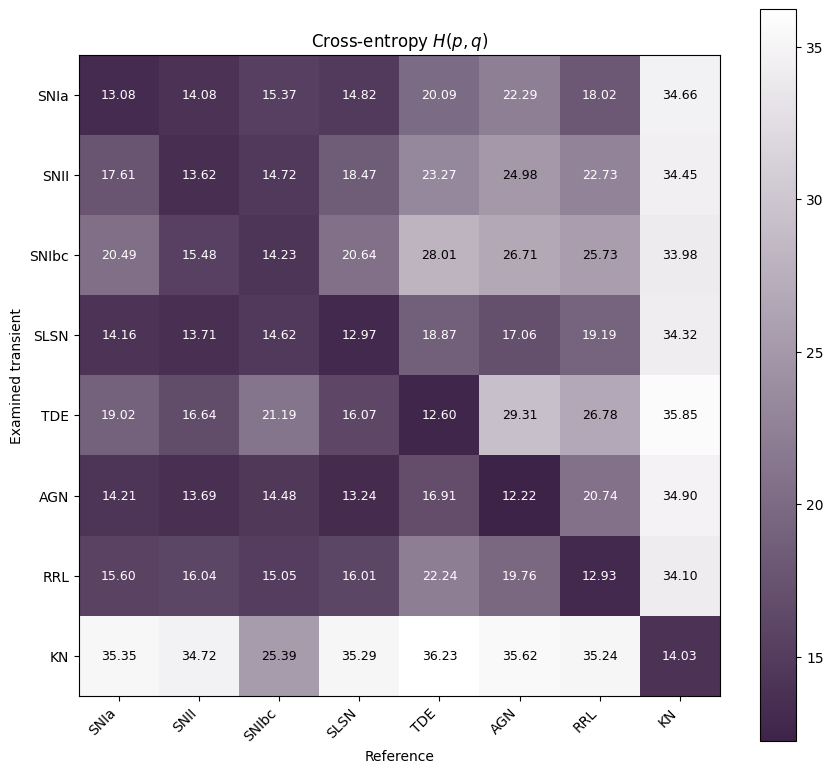

In [41]:
classes = Names

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(H, cmap=cmap_medium)

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))

ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticklabels(classes)

ax.set_xlabel("Reference")
ax.set_ylabel("Examined transient")
ax.set_title(r"Cross-entropy $H(p,q)$")

# Adaptive text color based on the displayed range
threshold = 0.5 * (np.nanmin(H) + np.nanmax(H))

for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(
            j,
            i,
            f"{H[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color="white" if H[i, j] < threshold else "black",
        )

cbar = fig.colorbar(im, ax=ax)
# cbar.set_label("Cross-entropy [nats]")

plt.tight_layout()
plt.savefig(
    "cross_entropy_8x8.pdf",
    bbox_inches="tight"
)
plt.show()

Regularization-Sensitivity Check

In [35]:
floors = [1e-20, 1e-18, 1e-14, 1e-12]

H_by_floor = {}

for floor_value in floors:
    H_test = np.empty(
        (len(Names), len(Names)),
        dtype=np.float64
    )

    for i, p_name in enumerate(Names):
        for j, q_name in enumerate(Names):
            H_test[i, j] = cross_entropy_counts(
                p_counts=DataDict[p_name]["data"],
                q_counts=DataDict[q_name]["data"],
                p_total=DataDict[p_name]["sum_total"],
                q_total=DataDict[q_name]["sum_total"],
                floor=floor_value,
            )

    H_by_floor[floor_value] = H_test

In [36]:
# Compare results

H_reference = H

for floor_value in floors:
    difference = H_by_floor[floor_value] - H_reference

    print(
        f"floor = {floor_value:.0e}: "
        f"max |ΔH| = {np.max(np.abs(difference)):.6e}, "
        f"mean |ΔH| = {np.mean(np.abs(difference)):.6e}"
    )

floor = 1e-20: max |ΔH| = 8.945539e+00, mean |ΔH| = 2.901862e+00
floor = 1e-18: max |ΔH| = 4.472769e+00, mean |ΔH| = 1.450931e+00
floor = 1e-14: max |ΔH| = 4.472769e+00, mean |ΔH| = 1.450931e+00
floor = 1e-12: max |ΔH| = 8.945539e+00, mean |ΔH| = 2.901862e+00


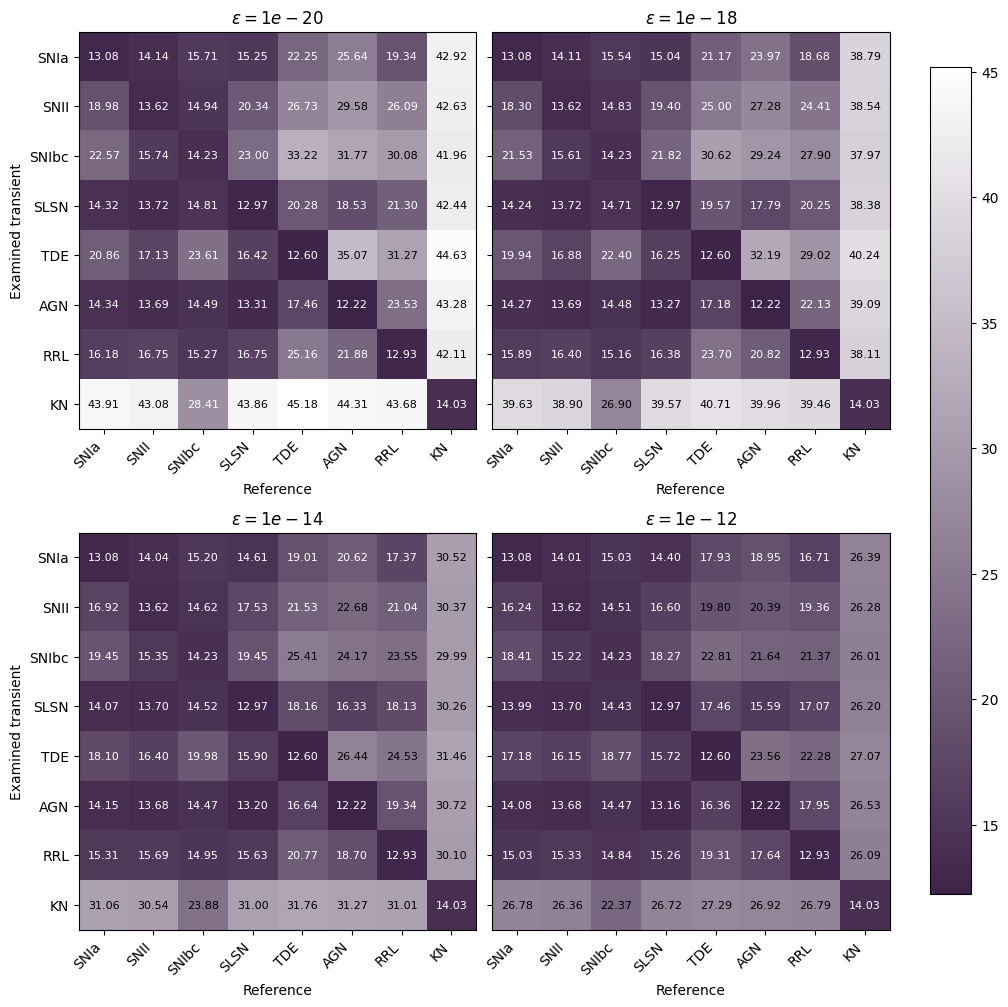

In [42]:
classes = Names
floors = sorted(H_by_floor.keys())

# fig, axes = plt.subplots(
#     1,
#     len(floors),
#     figsize=(5 * len(floors), 5),
#     constrained_layout=True,
# )

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 10),
    constrained_layout=True,
)

axes = axes.ravel()

# Common color scale
vmin = min(np.min(H_by_floor[f]) for f in floors)
vmax = max(np.max(H_by_floor[f]) for f in floors)

for ax, floor in zip(axes, floors):

    H_plot = H_by_floor[floor]

    im = ax.imshow(
        H_plot,
        cmap=cmap_medium,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))

    ax.set_xticklabels(classes, rotation=45, ha="right")

    if ax in (axes[0], axes[2]):
        ax.set_yticklabels(classes)
        ax.set_ylabel("Examined transient")
    else:
        ax.set_yticklabels([])

    ax.set_xlabel("Reference")
    ax.set_title(rf"$\epsilon={floor:.0e}$")

    threshold = 0.5 * (np.nanmin(H_plot) + np.nanmax(H_plot))

    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(
                j,
                i,
                f"{H_plot[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if H_plot[i, j] < threshold else "black",
            )

cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.9,
)

plt.savefig(
    "cross_entropy_floor_comparison.pdf",
    bbox_inches="tight",
)

plt.show()